In [203]:
# Attributes, columns, dimensions, variables   ------- (same name)

In [204]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns

In [205]:
df = pd.read_csv("ShopData.csv")

In [206]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [207]:
df.shape

(200, 5)

In [208]:
data = df.iloc[:, 3:5].values # used to extract as pairs
data

array([[ 15,  39],
       [ 15,  81],
       [ 16,   6],
       [ 16,  77],
       [ 17,  40],
       [ 17,  76],
       [ 18,   6],
       [ 18,  94],
       [ 19,   3],
       [ 19,  72],
       [ 19,  14],
       [ 19,  99],
       [ 20,  15],
       [ 20,  77],
       [ 20,  13],
       [ 20,  79],
       [ 21,  35],
       [ 21,  66],
       [ 23,  29],
       [ 23,  98],
       [ 24,  35],
       [ 24,  73],
       [ 25,   5],
       [ 25,  73],
       [ 28,  14],
       [ 28,  82],
       [ 28,  32],
       [ 28,  61],
       [ 29,  31],
       [ 29,  87],
       [ 30,   4],
       [ 30,  73],
       [ 33,   4],
       [ 33,  92],
       [ 33,  14],
       [ 33,  81],
       [ 34,  17],
       [ 34,  73],
       [ 37,  26],
       [ 37,  75],
       [ 38,  35],
       [ 38,  92],
       [ 39,  36],
       [ 39,  61],
       [ 39,  28],
       [ 39,  65],
       [ 40,  55],
       [ 40,  47],
       [ 40,  42],
       [ 40,  42],
       [ 42,  52],
       [ 42,  60],
       [ 43,

In [209]:
data.ndim

2

In [210]:
sil_scores = []
scre = 0
kn = 2
for k in range(2,9):
  kmeans = KMeans(n_clusters=k, init="k-means++", random_state=5)
  label = kmeans.fit_predict(data)
  sil_score = silhouette_score(data, label)
  if scre < sil_score:
    scre = sil_score
    kn = k
  sil_scores.append(sil_score)
  print(f"Cluster: {k}; Silhouette Score: {sil_score}")




Cluster: 2; Silhouette Score: 0.3117892685561811
Cluster: 3; Silhouette Score: 0.38308008111229286
Cluster: 4; Silhouette Score: 0.4931963109249047
Cluster: 5; Silhouette Score: 0.5532176107575425
Cluster: 6; Silhouette Score: 0.5423120971494979
Cluster: 7; Silhouette Score: 0.5321706886465517
Cluster: 8; Silhouette Score: 0.49931779403714205


In [211]:
label

array([0, 4, 6, 4, 0, 4, 6, 4, 6, 4, 6, 4, 6, 4, 6, 4, 0, 4, 0, 4, 0, 4,
       6, 4, 6, 4, 0, 4, 0, 4, 6, 4, 6, 4, 6, 4, 6, 4, 0, 4, 0, 4, 0, 1,
       0, 4, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 1, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5, 2, 5,
       2, 5, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 7, 3, 7, 3, 7, 3,
       7, 3], dtype=int32)

Text(0, 0.5, 'Silhouette Score')

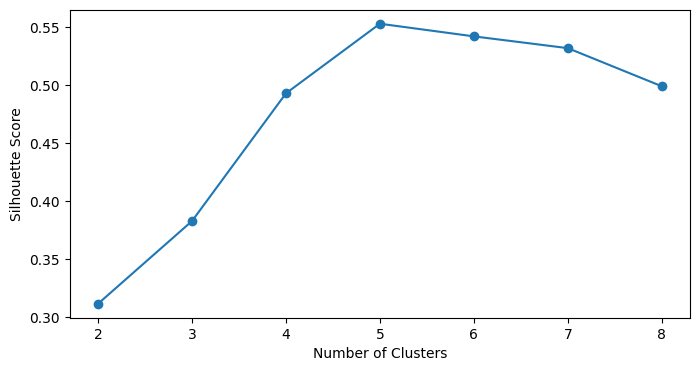

In [212]:
frame = pd.DataFrame({"Cluster" : range(2,9), "Silhouette Score" : sil_scores})
plt.figure(figsize=(8,4))
plt.plot(frame["Cluster"], frame["Silhouette Score"], marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

In [213]:
kmns = KMeans(n_clusters=5, init = "k-means++", max_iter=300, random_state=5)
y_kmeans = kmns.fit_predict(data)
print(y_kmeans)
center = kmns.cluster_centers_
center

[0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0 4 0
 4 0 4 0 4 0 1 0 4 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 3 2 3 1 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 1 3 2 3 2 3
 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3 2
 3 2 3 2 3 2 3 2 3 2 3 2 3 2 3]


array([[26.30434783, 20.91304348],
       [55.0875    , 49.7125    ],
       [87.75      , 17.58333333],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636]])

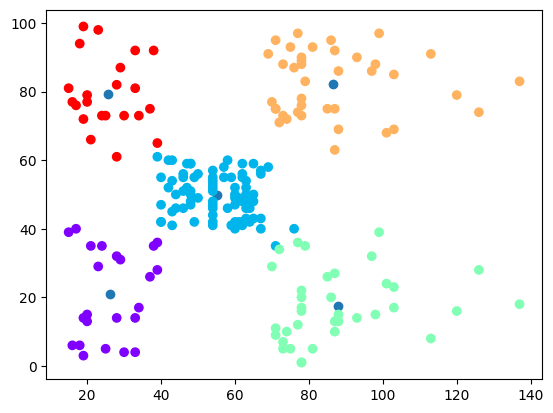

In [214]:
plt.scatter(center[:,0], center[:,1], marker="o", )
plt.scatter(data[:,0], data[:,1], c=y_kmeans, cmap="rainbow")

<Axes: xlabel='Annual Income (k$)', ylabel='Spending Score (1-100)'>

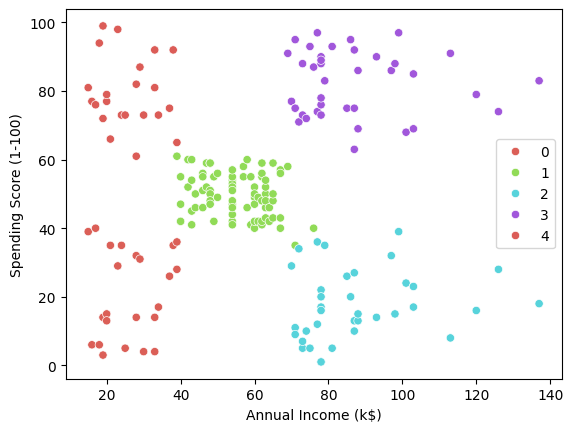

In [215]:
sns.scatterplot(data=df, x=df["Annual Income (k$)"], y=df["Spending Score (1-100)"], hue=y_kmeans
                , palette="hls")

In [216]:
clusterdf = pd.DataFrame({**df, "Cluster" : y_kmeans})
clusterdf.sort_values(by="Cluster")

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
2,3,Female,20,16,6,0
6,7,Female,35,18,6,0
4,5,Female,31,17,40,0
12,13,Female,58,20,15,0
...,...,...,...,...,...,...
27,28,Male,35,28,61,4
19,20,Female,35,23,98,4
17,18,Male,20,21,66,4
21,22,Male,25,24,73,4


In [217]:
clusterdf

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,0
1,2,Male,21,15,81,4
2,3,Female,20,16,6,0
3,4,Female,23,16,77,4
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,3
196,197,Female,45,126,28,2
197,198,Male,32,126,74,3
198,199,Male,32,137,18,2


In [222]:
SSE = []
clusMn = 2
clusMx = 11
for cluster in range(clusMn,clusMx):
    kmeans = KMeans(n_clusters = cluster, init='k-means++', random_state=5)
    kmeans.fit(data)
    SSE.append(kmeans.inertia_)


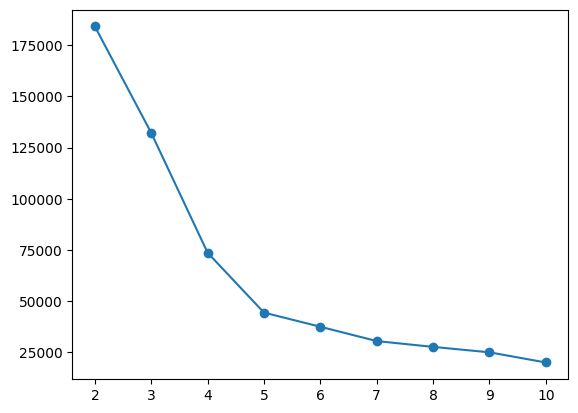

In [223]:
frame = pd.DataFrame({"Cluster" : range(clusMn,clusMx), "SSE" : SSE})
plt.plot(frame["Cluster"], frame["SSE"], marker="o")